In [ ]:
import pandas as pd


df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')
df.head()

In [ ]:
# Task 2: Number of rows and columns

rows,columns=df.shape
print(f"The Dataset has {rows} rows, and {columns} columns.")

In [ ]:
# Task 3: Display the last 75 rows
df.tail(75)

In [ ]:
#check the missing column data
df.isnull().sum()


For the Operator and Type columns, I will use Mode Imputation because these are categorical variables; filling gaps with the most frequent value is statistically the most likely representation of the data. For the numerical columns Aboard and Fatalities, I will use Median Imputation because it is more robust than the mean and won't be skewed by extreme outliers in the crash data. Finally, for descriptive text columns like Route, Summary, and Location, I will fill missing values with a Constant String ('Unknown') to preserve the integrity of the records without introducing false information.

In [ ]:
# Task 5: Create a new dataframe 'fatality_locations'
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

# Display the first few rows to confirm
fatality_locations.head()

In [ ]:
#Task 6: Highest Fatalities from  Data
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]

#Result
print(f"The highest number of fatalities was {max_fatalities_row['Fatalities']} on {max_fatalities_row['Date']}.")

In [ ]:
# Task 7: Compare 'Aboard' to 'Fatalities' and find zero-fatality crashes

zero_fatalities_df = fatality_locations[fatality_locations['Fatalities'] == 0]
num_zero_fatalities = len(zero_fatalities_df)

# Display the comparison for the first few rows and the count

print(f"Number of recorded crashes with no fatalities: {num_zero_fatalities}")
fatality_locations[['Aboard', 'Fatalities']].head()

In [ ]:
# Task 8: Spliting the 'Location' column into 'Region' and 'State/Country'
split_data = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

# Assigning the split parts to new columns
fatality_locations['Region'] = split_data[0]
fatality_locations['State/Country'] = split_data[1]

# Displaying the first few rows to verify the split
fatality_locations[['Location', 'Region', 'State/Country']].head()


In [ ]:
# Task 9: Ordering the dataframe by fatalities from highest to lowest and select the first 100

top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

# Testing the top 5 to confirm sorting
top_100_fatalities.head()

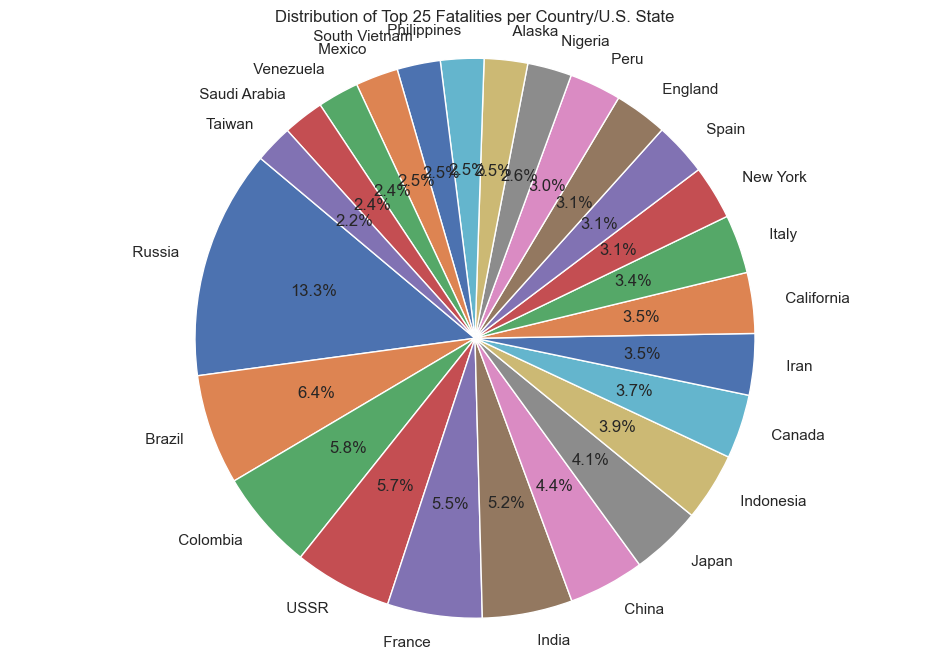

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 10: Top 25 fatalities per Country/State

# Group by the new column and sum the fatalities
country_fatalities = fatality_locations.groupby('State/Country')['Fatalities'].sum().sort_values(ascending=False).head(25)

# using seaborn
sns.set_theme(style="whitegrid")

# Generate the pie chart
plt.figure(figsize=(12, 8))
plt.pie(country_fatalities, labels=country_fatalities.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Top 25 Fatalities per Country/U.S. State')
plt.axis('equal')
plt.show()